In [79]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Загрузка данных

Это URL-адрес набора данных по цветкам ириса:

https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv


In [80]:
# Присвоим переменной «url» ссылку на датасет:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"



# создаем лист с названием столбцов:
cols = ['Sex','Length','Diameter','Height','Whole_weight',
        'Shucked_weight','Viscera_weight','Shell_weight','Rings']

# используем Pandas read_csv():
dataset = pd.read_csv(url, names=cols)


# Анализ данных

In [81]:
# размер датасета, 150 записей, 5 столбцов

dataset.shape

(4177, 9)

In [82]:
# отображаем первые 10 сстрок датасета

dataset.head(10)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,F,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


In [83]:
import mpl_toolkits.mplot3d  # noqa: F401


from sklearn import datasets
from sklearn.cluster import KMeans

In [84]:
# Метод Pandas info()  выводит очень много информации о наборе данных - количество записей,
# количество ненулевых значений в каждом столбце, тип данных в столбце

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [85]:
# Pandas describe() используется для просмотра  основной статистической информации, таких как процентиль, среднее,
# стандартное отклонение и т.д. фрейма данных или ряда числовых значений:

dataset.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [86]:
dataset['Sex'].unique()

array(['M', 'F', 'I'], dtype=object)

In [87]:
# Теперь проверим количество строк, которое принадлежит каждому классу:

dataset['Sex'].value_counts()

,count
Sex,
M,1528
I,1342
F,1307


Видим, что набор данных сбалансированный. В каждом классе 50 записей. Всего классов 3

# Визуализация данных

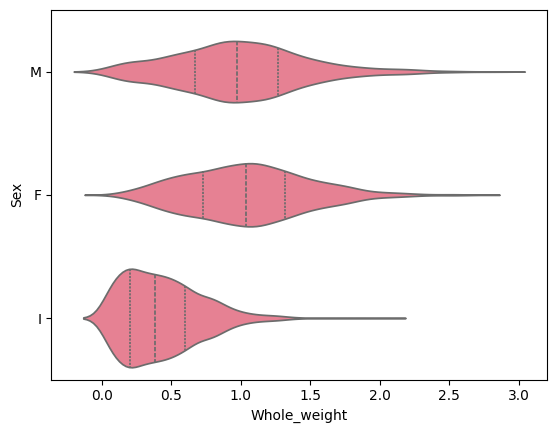

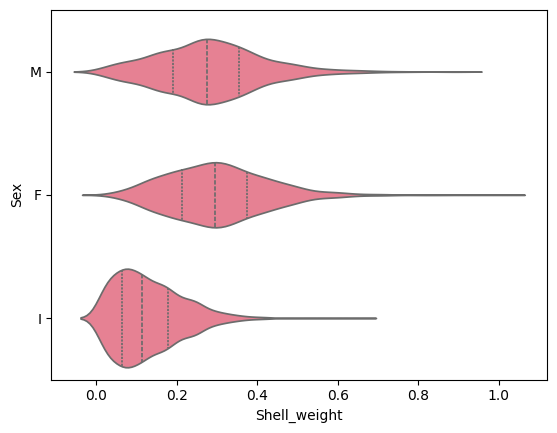

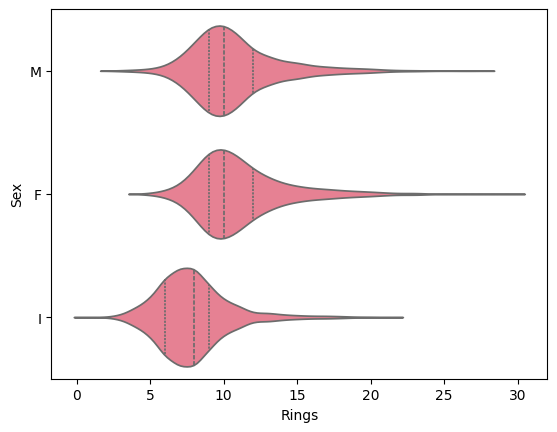

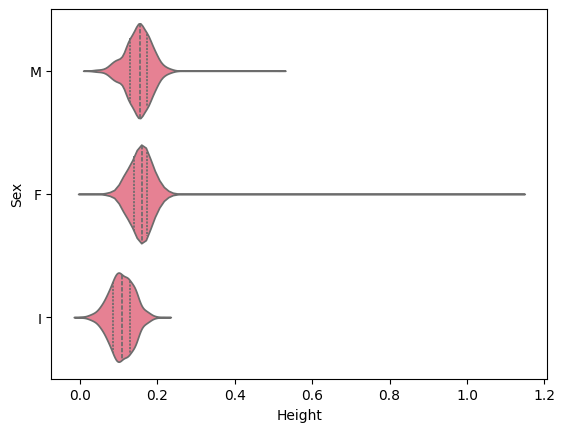

In [88]:
from scipy.linalg import dft
# Скрипичный график.
# Используется для проверки сравнения распределения переменных:

sns.violinplot(y='Sex', x='Whole_weight', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y='Sex', x='Shell_weight', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y='Sex', x='Rings', data=dataset, inner='quartile')
plt.show()
sns.violinplot(y='Sex', x='Height', data=dataset, inner='quartile')
plt.show()

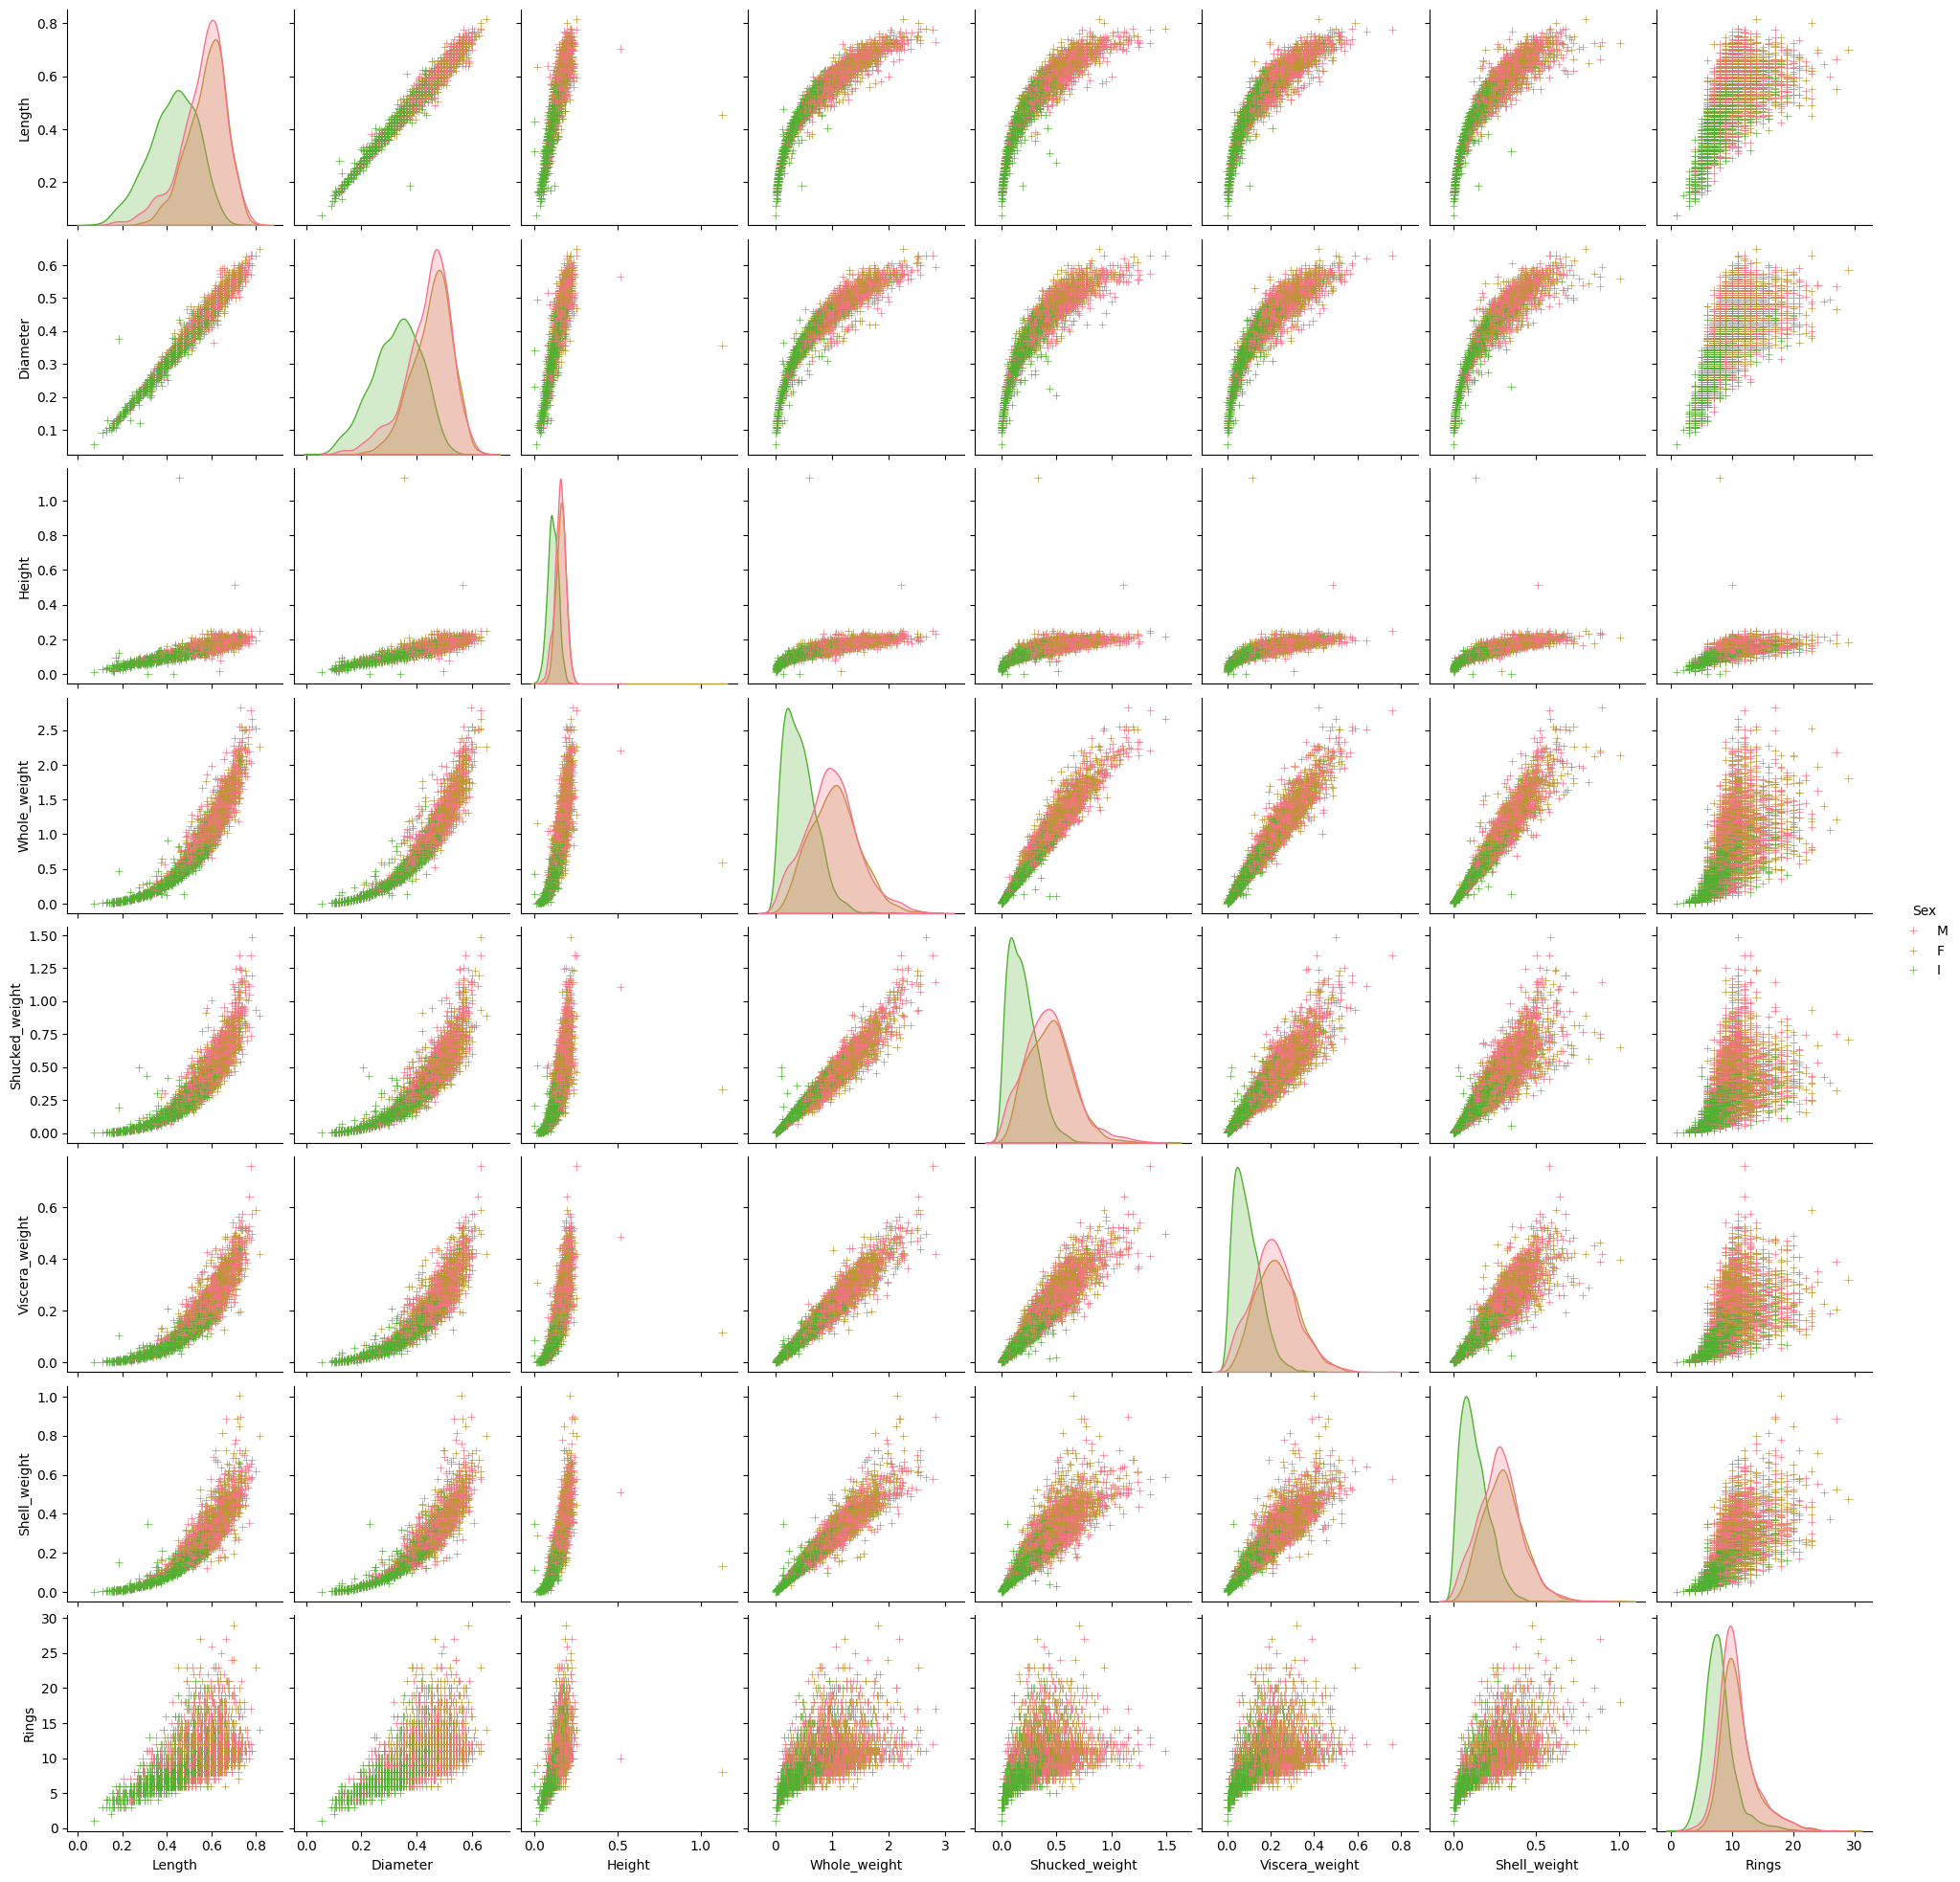

In [89]:
# Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot:

sns.pairplot(dataset, hue='Sex', markers='+')
plt.show()

Видим, что Iris-Setosa отличается от обоих других видов по всем признакам.

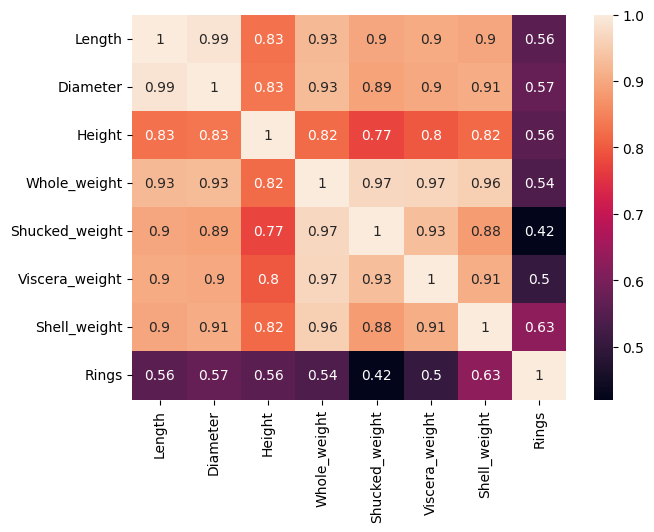

In [90]:
# Тепловая карта
# Построение тепловой карты для проверки корреляции.
# dataset.corr() используется для поиска попарной корреляции всех столбцов в кадре данных.

plt.figure(figsize=(7,5))
sns.heatmap(dataset.corr(numeric_only = True), annot=True)
plt.show()

Очень подробное и понятное описание возможностей построения графиков с помощью Matplotlib и Pandas с примерами кода можно найти здесь:

https://colab.research.google.com/drive/1ggUqm3C-Jk3dcMeibMW88FZLu7vtJ2k8?usp=sharing


# Построение модели

## Разделение набора данных

Y  - целевая переменная, которую предсказываем. Мы ищем зависимость этой переменной от соответствующих фич.  В нашем случае это столбец class.

В X складываем весь набор данных без целевой переменной.


In [91]:
X = dataset.drop(['Sex'], axis=1)
y = dataset['Sex']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (4177, 8) | y shape: (4177,) 


X имеет 150 строк и 4 столбца, тогда как Y имеет 150 строк и только один столбец.


## Train Test разделение

Разделяем наш набор данных на обучающий (train) и тестовый (test) с помощью train_test_split(), мы берем 80% данных для обучения нашей модели и 20% оставляем в качестве проверочного набора данных:

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

In [93]:
import scipy.stats as stats

y_mapped = y.map({'M': 0, 'F': 1, 'I': 2})

# почему важно перемешивать и делать train и test статистически не различимыми по целевой переменной
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.30, shuffle=True)

stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(1.6380090727926988), pvalue=np.float64(0.10149515716315266), df=np.float64(4175.0))

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.20, random_state=15, stratify=y_mapped)

stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(-0.010589884681145663), pvalue=np.float64(0.9915511584104248), df=np.float64(4175.0))

## Обучение и выбор оптимальной модели

Далее попробуем следующие алгоритмы:

Logistic Regression (LR) </br>
Linear Discriminant Analysis (LDA)</br>
K-Nearest Neighbors (KNN)</br>
Classification and Regression Trees (CART)</br>
Gaussian Naive Bayes (NB)</br>
Support Vector Machines (SVM)</br>

In [95]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
  kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  model_names.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.555522 (0.029794)
LDA: 0.549536 (0.028439)
KNN: 0.519302 (0.022919)
CART: 0.497167 (0.027035)
NB: 0.519912 (0.026013)
SVC: 0.537857 (0.017412)


LinearDiscriminantAnalysis и Наивный Байесовский классификатор показали лучшие метрики среди всех алгоритмов.
Далее работаем с LinearDiscriminantAnalysis.

Давайте обучим модель LDA на нашем обучающем наборе и сделаем прогноз на тестовом наборе на следующем шаге.

## Обучение конкретной модели
Определяем нашу модель LDA
После этого подгоняем/обучаем модель на X_train и Y_train с помощью метода .fit().
Затем мы делаем прогноз на X_test с помощью метода .predict().

In [96]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

sk LDA accuracy: 0.5394736842105263
sk LDA prediction: [1 2 2 1 0 0 2 0 1 1 2 0 0 2 2 0 2 1 2 2 2 0 1 2 1 1 0 2 1 2 2 0 0 0 0 0 2
 1 1 1 0 0 2 1 0 1 2 2 1 2 0 0 2 2 2 2 2 2 1 2 1 1 0 2 0 0 0 0 2 2 0 1 1 2
 2 0 1 2 0 2 2 0 2 0 0 1 0 2 2 0 2 2 2 0 0 0 1 2 2 0 2 2 0 2 0 0 0 0 0 1 2
 0 0 0 1 1 1 0 0 0 1 0 1 1 1 1 0 2 1 1 1 0 2 1 1 0 2 0 0 1 2 0 2 1 0 2 1 0
 2 2 1 2 0 2 1 2 0 2 0 1 1 1 1 2 2 2 2 1 0 0 2 1 2 1 0 0 0 2 2 2 0 1 0 1 2
 0 2 2 1 2 0 2 1 2 1 0 2 0 2 2 0 1 1 0 0 1 0 0 2 2 1 0 0 0 0 0 2 2 0 2 2 0
 2 1 1 2 2 0 2 2 1 2 2 1 2 2 0 0 2 2 0 0 2 0 2 1 1 2 1 1 0 2 1 2 0 2 0 0 2
 2 0 0 0 2 0 1 0 2 0 0 2 2 1 0 0 0 2 0 0 2 0 2 0 0 0 0 0 2 0 2 2 0 0 2 0 0
 0 2 2 0 1 0 0 0 0 1 0 0 1 2 2 2 1 1 0 0 1 2 1 2 1 0 2 0 0 2 2 0 0 2 0 1 2
 1 1 0 2 1 1 1 0 0 0 0 2 2 0 1 2 0 0 2 0 1 2 0 2 0 0 1 0 1 0 0 1 0 0 0 1 0
 0 2 0 2 0 1 2 0 0 2 0 2 2 0 2 2 2 1 1 1 2 2 0 2 1 0 1 2 2 1 0 0 2 2 1 2 0
 0 1 2 0 0 1 1 0 0 2 0 1 1 2 2 1 2 0 2 0 0 2 0 1 0 0 1 2 1 2 0 0 1 0 2 2 1
 1 2 2 2 0 2 0 0 2 0 0 2 0 2 1 1 2 0 1 2 2 0 

## Визуализация решения

<Axes: title={'center': 'LDA surface with original features'}>

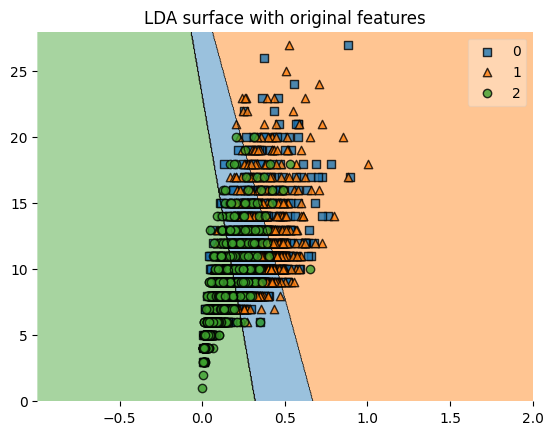

In [101]:
from mlxtend.plotting import plot_decision_regions

# Создадим целевой вектор y_2d
# Преобразуем классы к классам 0, 1, 2 соответственно
#y_s = y_train.map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
y_s = y_train
X_2d= X_train[['Shell_weight',	'Rings']].values

y_2d = y_s.values


sk_lda1 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda1.fit(X_2d, y_2d)

plt.title('LDA surface with original features')
plot_decision_regions(
    	X=X_2d,
    	y=y_2d,
    	clf=sk_lda1)

<Axes: title={'center': 'LDA surface with transformed features'}>

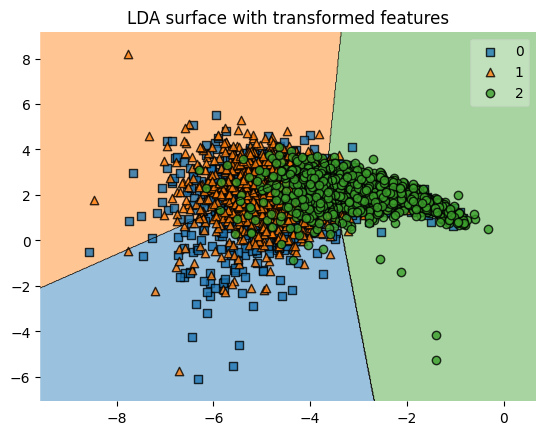

In [102]:
df = dataset["Sex"].map({'M': 0, 'F': 1, 'I': 2})

Xs = dataset[['Shell_weight',	'Rings']]
ys = df.values

sk_lda2 = LinearDiscriminantAnalysis(solver='eigen')
X1_lda = sk_lda2.fit(X, ys).transform(X)

Xs = X1_lda

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(X1_lda, ys, random_state=0)

sk_lda2.fit(X1_lda_train, y1_train)

plt.title('LDA surface with transformed features')
plot_decision_regions(X=X1_lda, y=ys, clf=sk_lda2)

In [99]:
predicted = sk_lda2.predict(X1_lda_test)


In [103]:
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition

## Accuray e AUC
'''
Теперь смотрим метрики.
НА ТЕСТОВОМ ДАТАСЕТЕ
'''
accuracy = metrics.accuracy_score(y1_test, predicted)#Оценим точность классификации.

'''
Получим результат
'''

## Precision e Recall
recall = metrics.recall_score(y1_test, predicted, average="weighted")
precision = metrics.precision_score(y1_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y1_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))

Recall (all 1s predicted right): 0.56
Precision (confidence when predicting a 1): 0.55
Detail:
              precision    recall  f1-score   support

           0       0.47      0.54      0.50       370
           1       0.50      0.34      0.41       316
           2       0.68      0.76      0.72       359

    accuracy                           0.56      1045
   macro avg       0.55      0.55      0.54      1045
weighted avg       0.55      0.56      0.55      1045

